# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** Gopi Agasthia S
**Student ID:** 2025AD05069
**Date:** 02 June 2026

#  Section 1 – Dataset Selection


* Dataset  : Adult Income Dataset (UCI ML Repository)
* Task     : Binary Classification
* Source   : https://archive.ics.uci.edu/ml/datasets/adult

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from sklearn.datasets import fetch_openml

matplotlib.use("Agg")
warnings.filterwarnings("ignore")

# 1.  LOAD DATASET

COLUMN_NAMES = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

TRAIN_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
)
TEST_URL  = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"
)

print(" 1  DATASET SELECTION")

print("\nLoading dataset from UCI ML Repository …")

try:
    train_df = pd.read_csv(
        TRAIN_URL, header=None, names=COLUMN_NAMES,
        sep=r",\s*", engine="python", na_values="?"
    )
    # The test file has a trailing period on labels and a junk first line
    test_df = pd.read_csv(
        TEST_URL, header=None, names=COLUMN_NAMES,
        sep=r",\s*", engine="python", na_values="?", skiprows=1
    )
    test_df["income"] = test_df["income"].str.rstrip(".")
    df = pd.concat([train_df, test_df], ignore_index=True)
    print("   ✓  Dataset loaded successfully from UCI repository.")
except Exception as e:
    print(f"   ✗  Remote load failed ({e}).\n"
          "      Falling back to OpenML …")
            # only for data fetch
    bunch = fetch_openml(data_id=1590, as_frame=True, parser="auto")
    df = bunch.frame
    df.rename(columns={"class": "income"}, inplace=True)
    print("   ✓  Dataset loaded successfully from OpenML.")

# Standardise label strings
df["income"] = df["income"].str.strip().str.rstrip(".")

 1  DATASET SELECTION

Loading dataset from UCI ML Repository …
   ✓  Dataset loaded successfully from UCI repository.


In [2]:
# 2.  BASIC DESCRIPTION
print("\nDataset Description\n")

n_samples, n_cols = df.shape
n_features        = n_cols - 1          # exclude target column

numeric_cols      = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols  = [c for c in df.columns
                     if c not in numeric_cols and c != "income"]

print(f"   Dataset name   : Adult Income (Census Income)")
print(f"   Source         : UCI ML Repository / OpenML (ID 1590)")
print(f"   Total samples  : {n_samples:,}")
print(f"   Total features : {n_features}  (≥ 10 ✓)")
print(f"     • Numeric    : {len(numeric_cols)}  → {numeric_cols}")
print(f"     • Categorical: {len(categorical_cols)}  → {categorical_cols}")
print(f"   Target column  : income  ('>50K' / '<=50K')")
print(f"   Missing values : {df.isnull().sum().sum():,} cells across "
      f"{(df.isnull().sum() > 0).sum()} columns")

print("\n   First 5 rows:")
print(df.head().to_string(index=False))

print("\n   Statistical summary (numeric features):")
print(df[numeric_cols].describe().round(2).to_string())

print("\n   Class distribution:")
class_counts = df["income"].value_counts()
for label, cnt in class_counts.items():
    pct = 100 * cnt / len(df)
    print(f"     {label:>6s}  →  {cnt:6,}  ({pct:.1f} %)")


Dataset Description

   Dataset name   : Adult Income (Census Income)
   Source         : UCI ML Repository / OpenML (ID 1590)
   Total samples  : 48,842
   Total features : 14  (≥ 10 ✓)
     • Numeric    : 6  → ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
     • Categorical: 8  → ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
   Target column  : income  ('>50K' / '<=50K')
   Missing values : 6,465 cells across 3 columns

   First 5 rows:
 age        workclass  fnlwgt education  education_num     marital_status        occupation  relationship  race    sex  capital_gain  capital_loss  hours_per_week native_country income
  39        State-gov   77516 Bachelors             13      Never-married      Adm-clerical Not-in-family White   Male          2174             0              40  United-States  <=50K
  50 Self-emp-not-inc   83311 Bachelors             13 Married-civ-spouse   Exec-mana

**TASK TYPE**

*  Task          : BINARY CLASSIFICATION
*  Target        : income  ∈  { '<=50K',  '>50K' }
*  Objective     : Given demographic and employment attributes of an individual, predict whether their annual income                          exceeds USD 50,000.
*  Label mapping : '>50K'  → 1  (positive / minority class) or '<=50K' → 0  (negative / majority class)


In [3]:
pos_pct = 100 * class_counts.get(">50K", 0) / len(df)
neg_pct = 100 * class_counts.get("<=50K", 0) / len(df)

Chosen metric : **F1-Score**  (macro-averaged)

   **Justification**
   1. Class imbalance  – The dataset is moderately imbalanced:
        '>50K'  ≈ {pos_pct:.1f} %   (minority / positive class)
        '<=50K' ≈ {neg_pct:.1f} %   (majority / negative class)
      Plain accuracy is misleading here; a trivial classifier that
      always predicts '<=50K' would achieve ≈ {neg_pct:.1f} % accuracy
      while being completely useless.

   2. Both precision and recall matter  – In an income-prediction
      context, false positives (predicting high income when it is
      not) and false negatives (missing actual high earners) both
      carry real-world costs (e.g., mis-targeted financial products,
      unfair credit decisions).  F1 balances these two concerns.

   3. Macro averaging  – Using macro-F1 (unweighted mean of per-class
      F1) ensures that performance on the minority class ('>50K') is
      given equal weight to the majority class, preventing the metric
      from being dominated by the larger group.

   Secondary metrics also reported
   * **Accuracy**          – for overall correctness reference
   * **ROC-AUC**           – threshold-independent discrimination ability
   * **Confusion matrix**  – detailed error breakdown

Generating exploratory plots
   ✓  EDA plot saved → dataset_eda.png


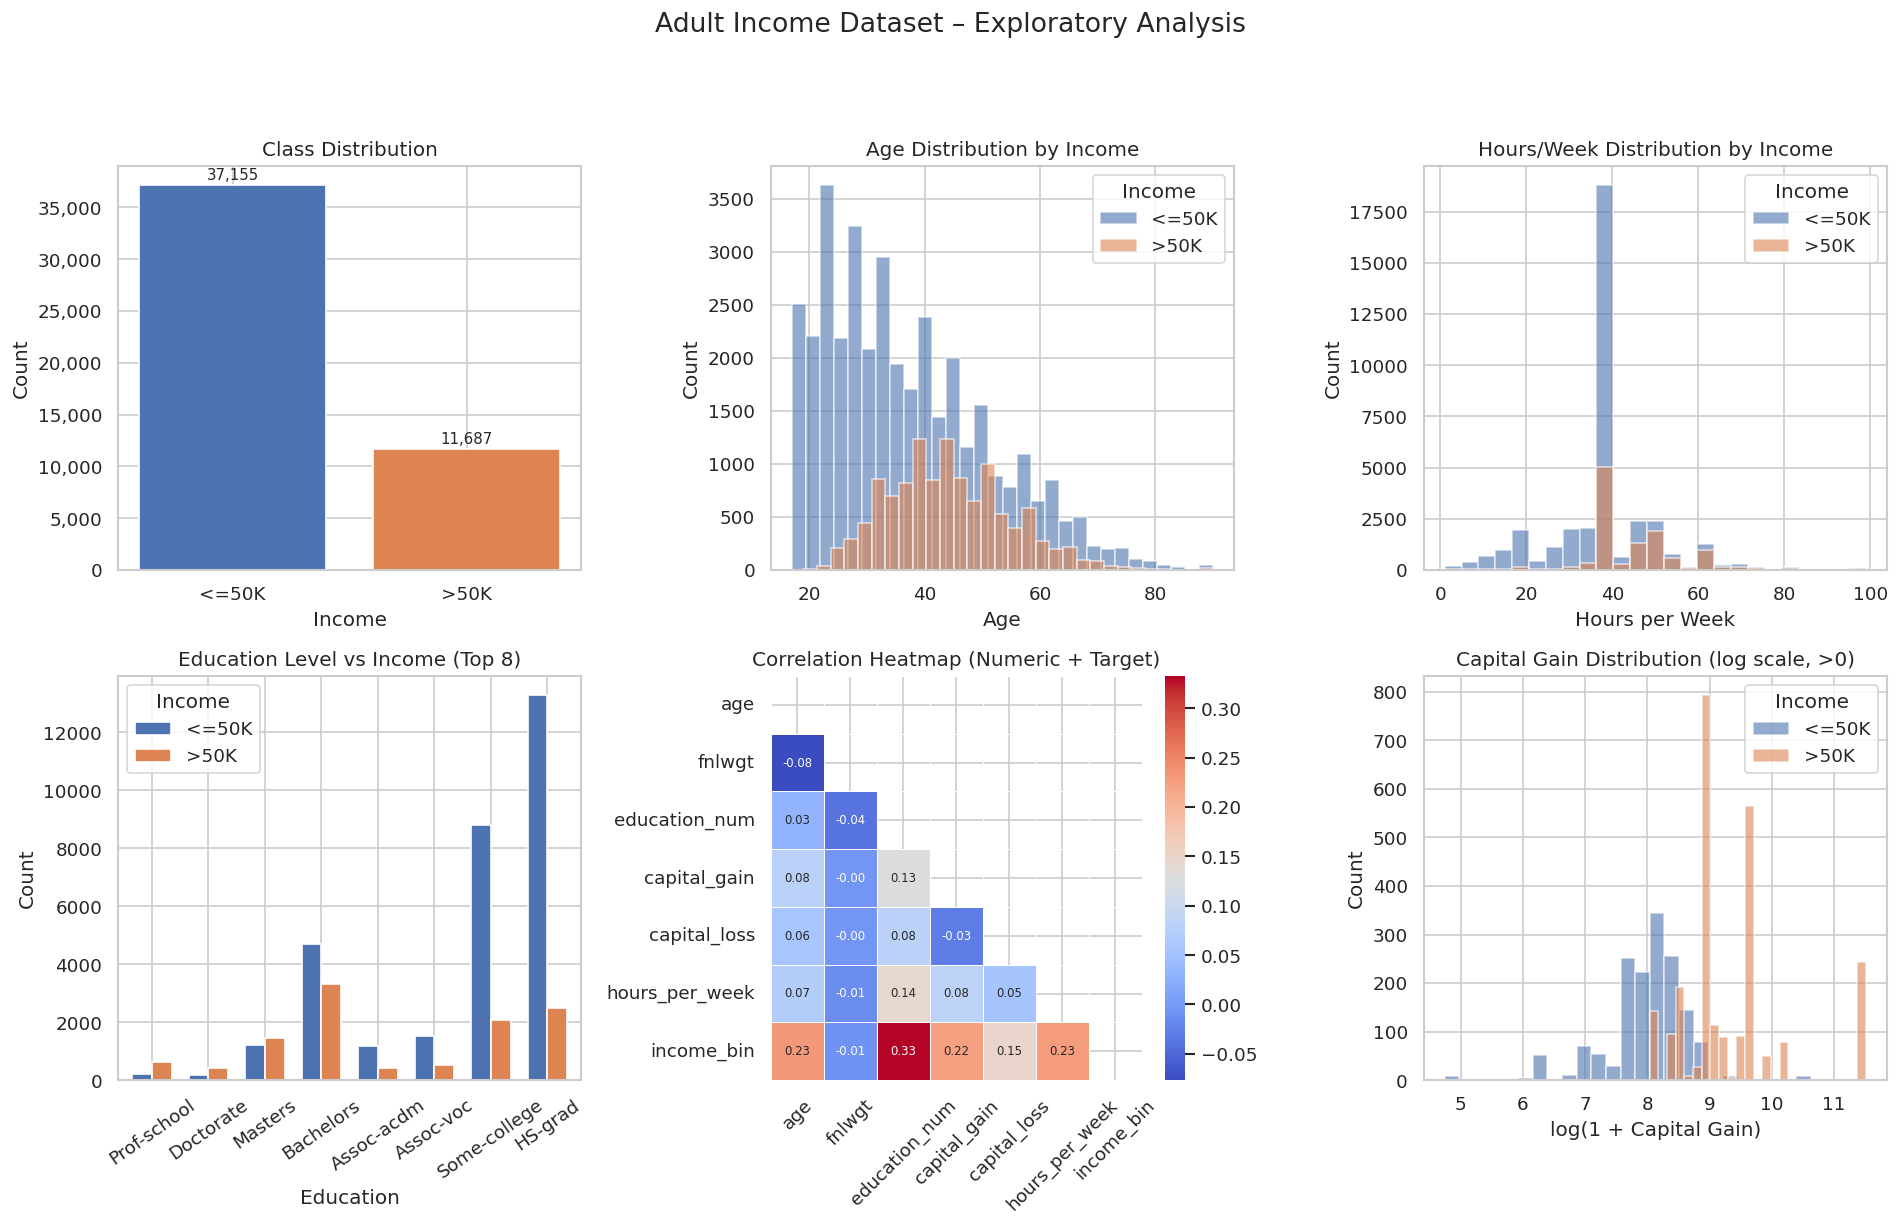

In [4]:
# Enable inline display (run once in notebook)
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np

print("Generating exploratory plots")

# Better resolution for notebooks
plt.rcParams["figure.dpi"] = 120

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Adult Income Dataset – Exploratory Analysis", fontsize=16, y=1.02)

# (a) Class distribution
ax = axes[0, 0]
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor="white")
ax.set_title("Class Distribution")
ax.set_xlabel("Income")
ax.set_ylabel("Count")
for bar, cnt in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{cnt:,}", ha="center", va="bottom", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# (b) Age distribution by income
ax = axes[0, 1]
for label, color in zip(["<=50K", ">50K"], colors):
    subset = df[df["income"] == label]["age"].dropna()
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="white")
ax.set_title("Age Distribution by Income")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend(title="Income")

# (c) Hours per week distribution
ax = axes[0, 2]
for label, color in zip(["<=50K", ">50K"], colors):
    subset = df[df["income"] == label]["hours_per_week"].dropna()
    ax.hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor="white")
ax.set_title("Hours/Week Distribution by Income")
ax.set_xlabel("Hours per Week")
ax.set_ylabel("Count")
ax.legend(title="Income")

# (d) Education level vs income
ax = axes[1, 0]
edu_order = (df.groupby("education")["income"]
               .apply(lambda s: (s == ">50K").mean())
               .sort_values(ascending=False)
               .index[:8])
edu_data = (df[df["education"].isin(edu_order)]
              .groupby(["education", "income"])
              .size()
              .unstack(fill_value=0))
edu_data = edu_data.loc[edu_order]
edu_data.plot(kind="bar", ax=ax, color=colors, edgecolor="white", width=0.7)
ax.set_title("Education Level vs Income (Top 8)")
ax.set_xlabel("Education")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Income")

# (e) Correlation heatmap
ax = axes[1, 1]
corr_df = df[numeric_cols].copy()
corr_df["income_bin"] = (df["income"] == ">50K").astype(int)
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap (Numeric + Target)")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

# (f) Capital gain distribution
ax = axes[1, 2]
for label, color in zip(["<=50K", ">50K"], colors):
    subset = df[(df["income"] == label) & (df["capital_gain"] > 0)]["capital_gain"]
    if len(subset):
        ax.hist(np.log1p(subset), bins=25, alpha=0.6,
                label=label, color=color, edgecolor="white")
ax.set_title("Capital Gain Distribution (log scale, >0)")
ax.set_xlabel("log(1 + Capital Gain)")
ax.set_ylabel("Count")
ax.legend(title="Income")

# Clean layout for notebooks
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save + Display
out_path = "dataset_eda.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"   ✓  EDA plot saved → {out_path}")

plt.show()
plt.close(fig)

# Section 2 – Dataset Preprocessing

In [5]:
# STEP 1 – Drop duplicates
print("\n[Step 1]  Removing duplicate rows")
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)
print(f"   Removed {before - after} duplicate rows.  Remaining: {after:,}")


[Step 1]  Removing duplicate rows
   Removed 52 duplicate rows.  Remaining: 48,790


In [6]:
# STEP 2 – Handle missing values
print("\n[Step 2]  Handling missing values")
missing_before = df.isnull().sum()
cols_with_missing = missing_before[missing_before > 0]
print(f"   Columns with missing values:\n{cols_with_missing.to_string()}")

# Categorical columns → fill with mode; numeric → fill with median
for col in cols_with_missing.index:
    is_categorical = (df[col].dtype == object or
                      pd.api.types.is_string_dtype(df[col]) or
                      str(df[col].dtype) in ("string", "object"))
    if is_categorical:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"   '{col}' (categorical) → filled with mode = '{mode_val}'")
    else:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"   '{col}' (numeric) → filled with median = {median_val}")

print(f"   Missing values after imputation: {df.isnull().sum().sum()}")


[Step 2]  Handling missing values
   Columns with missing values:
workclass         2795
occupation        2805
native_country     856
   'workclass' (categorical) → filled with mode = 'Private'
   'occupation' (categorical) → filled with mode = 'Prof-specialty'
   'native_country' (categorical) → filled with mode = 'United-States'
   Missing values after imputation: 0


In [7]:
print("\n[Step 3]  Encoding target variable …")

if df["income"].dtype == "object":
    df["income"] = (df["income"].str.strip() == ">50K").astype(int)
    print("   Encoded: '>50K' → 1, '<=50K' → 0")
else:
    print("   Skipped: income already encoded")

print(f"   Class counts:\n{df['income'].value_counts().to_string()}")


[Step 3]  Encoding target variable …
   Encoded: '>50K' → 1, '<=50K' → 0
   Class counts:
income
0    37109
1    11681


In [8]:
# STEP 4 – Encode categorical features (One-Hot Encoding)
print("\n[Step 4]  Encoding categorical features (One-Hot Encoding)")

# Identify categorical feature columns (exclude target)
cat_feature_cols = df.select_dtypes(include="object").columns.tolist()
print(f"   Categorical columns to encode: {cat_feature_cols}")

# Manual one-hot encoding using pandas get_dummies (allowed – it's pandas)
df_encoded = pd.get_dummies(df, columns=cat_feature_cols, drop_first=False)

# Convert boolean columns produced by get_dummies to int
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"   Shape before encoding : {df.shape}")
print(f"   Shape after  encoding : {df_encoded.shape}")


[Step 4]  Encoding categorical features (One-Hot Encoding)
   Categorical columns to encode: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
   Shape before encoding : (48790, 15)
   Shape after  encoding : (48790, 106)


In [9]:
# STEP 5 – Separate features and target
print("\n[Step 5]  Separating features (X) and target (y) ")
X = df_encoded.drop(columns=["income"]).values.astype(np.float64)
y = df_encoded["income"].values.astype(np.int32)
feature_names = df_encoded.drop(columns=["income"]).columns.tolist()
print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")
print(f"   Total features after encoding: {X.shape[1]}")


[Step 5]  Separating features (X) and target (y) 
   X shape : (48790, 105)
   y shape : (48790,)
   Total features after encoding: 105


In [10]:
# STEP 6 – Train-Test Split (80 / 20)  — using sklearn ONLY for split
print("\n[Step 6]  Train-Test Split (80 % train / 20 % test)")
from sklearn.model_selection import train_test_split   # allowed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"   Training set   : {X_train.shape[0]:,} samples  ({100*X_train.shape[0]/len(X):.1f} %)")
print(f"   Test set       : {X_test.shape[0]:,} samples  ({100*X_test.shape[0]/len(X):.1f} %)")
print(f"   Train class dist: {np.bincount(y_train)}")
print(f"   Test  class dist: {np.bincount(y_test)}")


[Step 6]  Train-Test Split (80 % train / 20 % test)
   Training set   : 39,032 samples  (80.0 %)
   Test set       : 9,758 samples  (20.0 %)
   Train class dist: [29687  9345]
   Test  class dist: [7422 2336]


In [11]:
# STEP 7 – Feature Scaling (StandardScaler) — sklearn allowed
print("\n[Step 7]  Feature Scaling (StandardScaler)")
from sklearn.preprocessing import StandardScaler       # allowed

# Scale only numeric columns; one-hot columns are already 0/1
numeric_feature_indices = [
    i for i, name in enumerate(feature_names)
    if not any(name.startswith(cat + "_") for cat in cat_feature_cols)
]
print(f"   Numeric feature indices to scale: {numeric_feature_indices}")
print(f"   Numeric feature names           : {[feature_names[i] for i in numeric_feature_indices]}")

scaler = StandardScaler()
X_train[:, numeric_feature_indices] = scaler.fit_transform(
    X_train[:, numeric_feature_indices]
)
X_test[:, numeric_feature_indices] = scaler.transform(
    X_test[:, numeric_feature_indices]
)

print(f"   Scaling complete.")
print(f"   Train numeric mean (post-scale, first 3): "
      f"{X_train[:, numeric_feature_indices[:3]].mean(axis=0).round(4)}")
print(f"   Train numeric std  (post-scale, first 3): "
      f"{X_train[:, numeric_feature_indices[:3]].std(axis=0).round(4)}")



[Step 7]  Feature Scaling (StandardScaler)
   Numeric feature indices to scale: [0, 1, 3, 4, 5]
   Numeric feature names           : ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
   Scaling complete.
   Train numeric mean (post-scale, first 3): [-0. -0.  0.]
   Train numeric std  (post-scale, first 3): [1. 1. 1.]



[Step 8]  Generating preprocessing summary plot 
   ✓  Preprocessing plot saved → preprocessing_summary.png


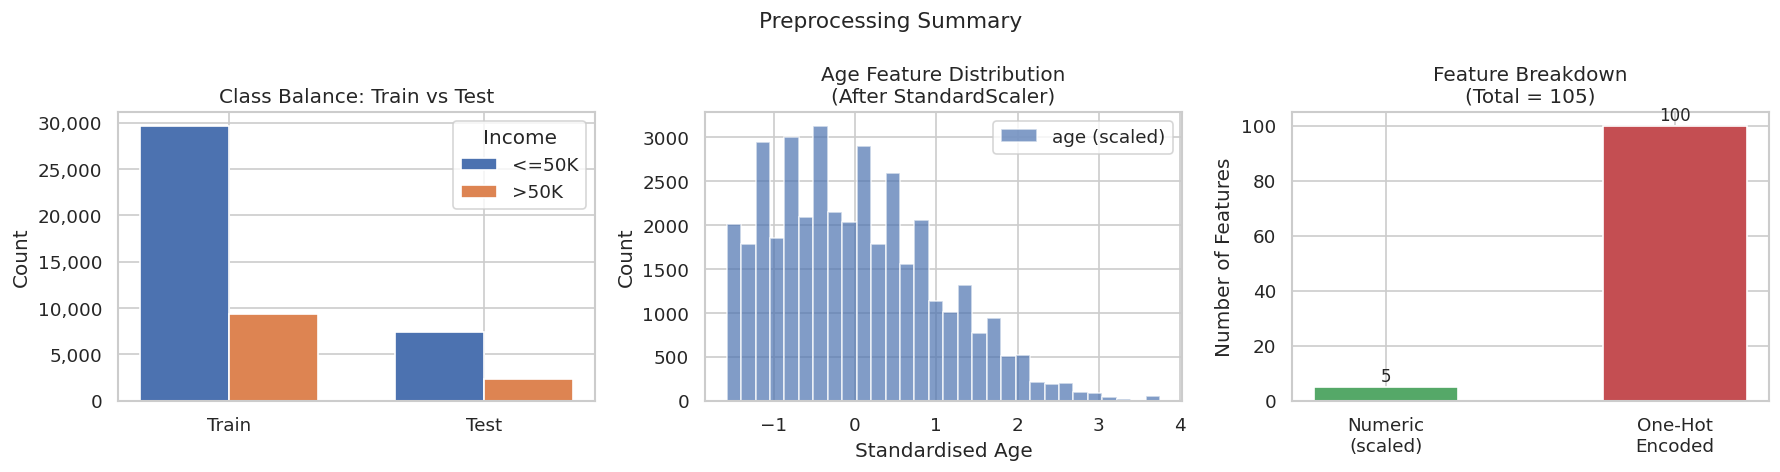

In [12]:
# STEP 8 – Preprocessing Summary Plot
print("\n[Step 8]  Generating preprocessing summary plot ")

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle("Preprocessing Summary", fontsize=13)

# (a) Train vs Test class balance
ax = axes2[0]
split_labels = ["Train", "Test"]
pos_counts   = [np.sum(y_train == 1), np.sum(y_test == 1)]
neg_counts   = [np.sum(y_train == 0), np.sum(y_test == 0)]
x_pos = np.arange(len(split_labels))
width = 0.35
ax.bar(x_pos - width/2, neg_counts, width, label="<=50K", color="#4C72B0", edgecolor="white")
ax.bar(x_pos + width/2, pos_counts, width, label=">50K",  color="#DD8452", edgecolor="white")
ax.set_xticks(x_pos)
ax.set_xticklabels(split_labels)
ax.set_title("Class Balance: Train vs Test")
ax.set_ylabel("Count")
ax.legend(title="Income")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# (b) Distribution of a numeric feature before vs after scaling
ax = axes2[1]
raw_age_idx = feature_names.index("age")
ax.hist(X_train[:, raw_age_idx], bins=30, alpha=0.7,
        color="#4C72B0", edgecolor="white", label="age (scaled)")
ax.set_title("Age Feature Distribution\n(After StandardScaler)")
ax.set_xlabel("Standardised Age")
ax.set_ylabel("Count")
ax.legend()

# (c) Feature count breakdown
ax = axes2[2]
n_num = len(numeric_feature_indices)
n_cat_enc = X.shape[1] - n_num
categories = ["Numeric\n(scaled)", "One-Hot\nEncoded"]
counts     = [n_num, n_cat_enc]
bar_colors = ["#55A868", "#C44E52"]
bars = ax.bar(categories, counts, color=bar_colors, edgecolor="white", width=0.5)
ax.set_title(f"Feature Breakdown\n(Total = {X.shape[1]})")
ax.set_ylabel("Number of Features")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(cnt), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
out_path2 = "preprocessing_summary.png"
plt.savefig(out_path2, dpi=150, bbox_inches="tight")
print(f"   ✓  Preprocessing plot saved → {out_path2}")


In [13]:
# PREPROCESSING SUMMARY
print("  PREPROCESSING SUMMARY\n")

print(f"""
  Step 1 – Duplicates removed    : {before - after}
  Step 2 – Missing value strategy: Mode imputation (categorical)
                                   Median imputation (numeric)
  Step 3 – Target encoding       : '>50K'→1, '<=50K'→0
  Step 4 – Categorical encoding  : One-Hot Encoding
                                   ({len(cat_feature_cols)} columns → {n_cat_enc} binary features)
  Step 5 – Feature / target split: X {X.shape}, y {y.shape}
  Step 6 – Train/Test split      : 80 % / 20 %  (stratified)
                                   Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}
  Step 7 – Feature scaling       : StandardScaler on {n_num} numeric features
  Final feature matrix           : {X_train.shape[1]} features
""")

print("  Preprocessed arrays ready for model training:")
print(f"    X_train : {X_train.shape}  (float64)")
print(f"    X_test  : {X_test.shape}  (float64)")
print(f"    y_train : {y_train.shape}  (int32)")
print(f"    y_test  : {y_test.shape}  (int32)")


  PREPROCESSING SUMMARY


  Step 1 – Duplicates removed    : 52
  Step 2 – Missing value strategy: Mode imputation (categorical)
                                   Median imputation (numeric)
  Step 3 – Target encoding       : '>50K'→1, '<=50K'→0
  Step 4 – Categorical encoding  : One-Hot Encoding
                                   (8 columns → 100 binary features)
  Step 5 – Feature / target split: X (48790, 105), y (48790,)
  Step 6 – Train/Test split      : 80 % / 20 %  (stratified)
                                   Train: 39,032  |  Test: 9,758
  Step 7 – Feature scaling       : StandardScaler on 5 numeric features
  Final feature matrix           : 105 features

  Preprocessed arrays ready for model training:
    X_train : (39032, 105)  (float64)
    X_test  : (9758, 105)  (float64)
    y_train : (39032,)  (int32)
    y_test  : (9758,)  (int32)


# Section 3 – Baseline Model (Logistic Regression from Scratch)

In [14]:
# Helper functions

def sigmoid(z):
    """Numerically stable sigmoid."""
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))


def binary_cross_entropy(y_true, y_pred_prob, eps=1e-12):
    """Binary cross-entropy loss (scalar)."""
    y_pred_prob = np.clip(y_pred_prob, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_pred_prob) +
                    (1 - y_true) * np.log(1 - y_pred_prob))


def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def compute_f1_macro(y_true, y_pred):
    """Macro-averaged F1 for binary labels {0, 1}."""
    f1_scores = []
    for cls in [0, 1]:
        tp = np.sum((y_pred == cls) & (y_true == cls))
        fp = np.sum((y_pred == cls) & (y_true != cls))
        fn = np.sum((y_pred != cls) & (y_true == cls))
        precision = tp / (tp + fp + 1e-12)
        recall    = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)
        f1_scores.append(f1)
    return float(np.mean(f1_scores))



In [15]:
# LogisticRegressionScratch class
class LogisticRegressionScratch:
    """
    Binary Logistic Regression implemented entirely from scratch
    using only NumPy.

    Parameters
    ----------
    learning_rate : float   – step size for gradient descent
    n_iterations  : int     – number of full-batch gradient descent steps
    lambda_reg    : float   – L2 regularisation strength (0 = no reg)
    verbose       : bool    – print loss every 100 iterations
    """

    def __init__(self, learning_rate=0.1, n_iterations=1000,
                 lambda_reg=0.01, verbose=True):
        self.lr          = learning_rate
        self.n_iter      = n_iterations
        self.lambda_reg  = lambda_reg
        self.verbose     = verbose

        # Initialised in fit()
        self.weights     = None   # shape (n_features,)
        self.bias        = None   # scalar
        self.loss_history = []    # loss at every iteration  ← REQUIRED

    # ----------------------------------------------------------
    # Weight initialisation
    # ----------------------------------------------------------
    def _initialise_weights(self, n_features):
        """Xavier / Glorot uniform initialisation."""
        limit = np.sqrt(6.0 / (n_features + 1))
        self.weights = np.random.uniform(-limit, limit, size=(n_features,))
        self.bias    = 0.0
        print(f"   Weights initialised (Xavier uniform):  "
              f"shape={self.weights.shape},  "
              f"range=[{self.weights.min():.4f}, {self.weights.max():.4f}]")

    # ----------------------------------------------------------
    # Forward pass
    # ----------------------------------------------------------
    def _forward(self, X):
        """
        Compute linear combination then apply sigmoid.
        Returns predicted probabilities, shape (n_samples,).
        """
        z = X @ self.weights + self.bias   # linear: (n,)
        return sigmoid(z)                  # probabilities: (n,)

    # ----------------------------------------------------------
    # Compute gradients
    # ----------------------------------------------------------
    def _compute_gradients(self, X, y_true, y_pred_prob):
        """
        Gradient of BCE loss w.r.t. weights and bias.
        Includes L2 regularisation on weights (not bias).

        dL/dw = (1/n) * Xᵀ(ŷ − y)  +  λ·w
        dL/db = (1/n) * Σ(ŷ − y)
        """
        n = X.shape[0]
        error = y_pred_prob - y_true                    # (n,)
        dw = (X.T @ error) / n + self.lambda_reg * self.weights
        db = np.mean(error)
        return dw, db

    # ----------------------------------------------------------
    # Fit (training loop)
    # ----------------------------------------------------------
    def fit(self, X, y):
        """
        Train the model using batch gradient descent.

        Parameters
        ----------
        X : np.ndarray, shape (n_samples, n_features)
        y : np.ndarray, shape (n_samples,)  – binary labels {0, 1}
        """
        n_samples, n_features = X.shape
        self._initialise_weights(n_features)
        self.loss_history = []

        print(f"\n   Training  |  lr={self.lr}  |  "
              f"iterations={self.n_iter}  |  λ={self.lambda_reg}")
        print(f"   {'Iter':>6}  {'Loss':>12}  {'Train Acc':>10}  {'Train F1':>10}")
        print("   " + "-" * 44)

        for i in range(1, self.n_iter + 1):

            # ── Forward pass ──────────────────────────────────
            y_prob = self._forward(X)

            # ── Compute loss ──────────────────────────────────
            loss = binary_cross_entropy(y, y_prob)
            # Add L2 regularisation term to loss (for monitoring)
            loss_reg = loss + (self.lambda_reg / 2) * np.sum(self.weights ** 2)
            self.loss_history.append(loss_reg)   # store every iteration

            # ── Compute gradients ─────────────────────────────
            dw, db = self._compute_gradients(X, y, y_prob)

            # ── Update weights  w = w – lr × grad ─────────────
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # ── Verbose logging ───────────────────────────────
            if self.verbose and (i % 100 == 0 or i == 1):
                y_pred_train = self.predict(X)
                acc = compute_accuracy(y, y_pred_train)
                f1  = compute_f1_macro(y, y_pred_train)
                print(f"   {i:>6}  {loss_reg:>12.6f}  {acc:>10.4f}  {f1:>10.4f}")

        print("   Training complete.")
        return self

    # ----------------------------------------------------------
    # Predict
    # ----------------------------------------------------------
    def predict(self, X, threshold=0.5):
        """
        Return binary class predictions {0, 1}.

        Parameters
        ----------
        X         : np.ndarray, shape (n_samples, n_features)
        threshold : float – decision boundary (default 0.5)

        Returns
        -------
        np.ndarray of int, shape (n_samples,)
        """
        probs = self._forward(X)
        return (probs >= threshold).astype(int)

    def predict_proba(self, X):
        """Return predicted probabilities for the positive class."""
        return self._forward(X)



In [16]:
#Train the model
print("\n[Train]  Fitting Logistic Regression baseline …\n")

np.random.seed(42)
baseline_model = LogisticRegressionScratch(
    learning_rate=0.1,
    n_iterations=1000,
    lambda_reg=0.01,
    verbose=True
)
baseline_model.fit(X_train, y_train.astype(np.float64))



[Train]  Fitting Logistic Regression baseline …

   Weights initialised (Xavier uniform):  shape=(105,),  range=[-0.2353, 0.2317]

   Training  |  lr=0.1  |  iterations=1000  |  λ=0.01
     Iter          Loss   Train Acc    Train F1
   --------------------------------------------
        1      1.177785      0.7597      0.4317
      100      0.430624      0.7966      0.6362
      200      0.400636      0.8191      0.7050
      300      0.389013      0.8288      0.7272
      400      0.382849      0.8332      0.7376
      500      0.379006      0.8356      0.7431
      600      0.376365      0.8378      0.7476
      700      0.374423      0.8395      0.7511
      800      0.372924      0.8403      0.7526
      900      0.371719      0.8410      0.7539
     1000      0.370718      0.8414      0.7550
   Training complete.


In [17]:
# Evaluate on train and test sets
print("\n[Evaluate]  Performance on Train and Test sets …")

y_train_pred = baseline_model.predict(X_train)
y_test_pred  = baseline_model.predict(X_test)

train_acc = compute_accuracy(y_train, y_train_pred)
test_acc  = compute_accuracy(y_test,  y_test_pred)
train_f1  = compute_f1_macro(y_train, y_train_pred)
test_f1   = compute_f1_macro(y_test,  y_test_pred)

print(f"\n   {'Metric':<20} {'Train':>10} {'Test':>10}")
print("   " + "-" * 42)
print(f"   {'Accuracy':<20} {train_acc:>10.4f} {test_acc:>10.4f}")
print(f"   {'Macro F1-Score':<20} {train_f1:>10.4f} {test_f1:>10.4f}")
print(f"   {'Final Loss':<20} {baseline_model.loss_history[-1]:>10.6f}")


[Evaluate]  Performance on Train and Test sets …

   Metric                    Train       Test
   ------------------------------------------
   Accuracy                 0.8414     0.8438
   Macro F1-Score           0.7550     0.7595
   Final Loss             0.370718


In [18]:
# Confusion matrix (manual)
def confusion_matrix_manual(y_true, y_pred):
    """Returns [[TN, FP], [FN, TP]] for binary labels."""
    TP = int(np.sum((y_pred == 1) & (y_true == 1)))
    TN = int(np.sum((y_pred == 0) & (y_true == 0)))
    FP = int(np.sum((y_pred == 1) & (y_true == 0)))
    FN = int(np.sum((y_pred == 0) & (y_true == 1)))
    return np.array([[TN, FP], [FN, TP]])

cm_test = confusion_matrix_manual(y_test, y_test_pred)
print(f"\n   Confusion Matrix (Test Set):")
print(f"                  Predicted 0   Predicted 1")
print(f"   Actual 0  :   {cm_test[0,0]:>10,}  {cm_test[0,1]:>12,}")
print(f"   Actual 1  :   {cm_test[1,0]:>10,}  {cm_test[1,1]:>12,}")


   Confusion Matrix (Test Set):
                  Predicted 0   Predicted 1
   Actual 0  :        7,006           416
   Actual 1  :        1,108         1,228



[Plot]  Generating baseline model plots …
   ✓  Baseline model plot saved → baseline_model.png


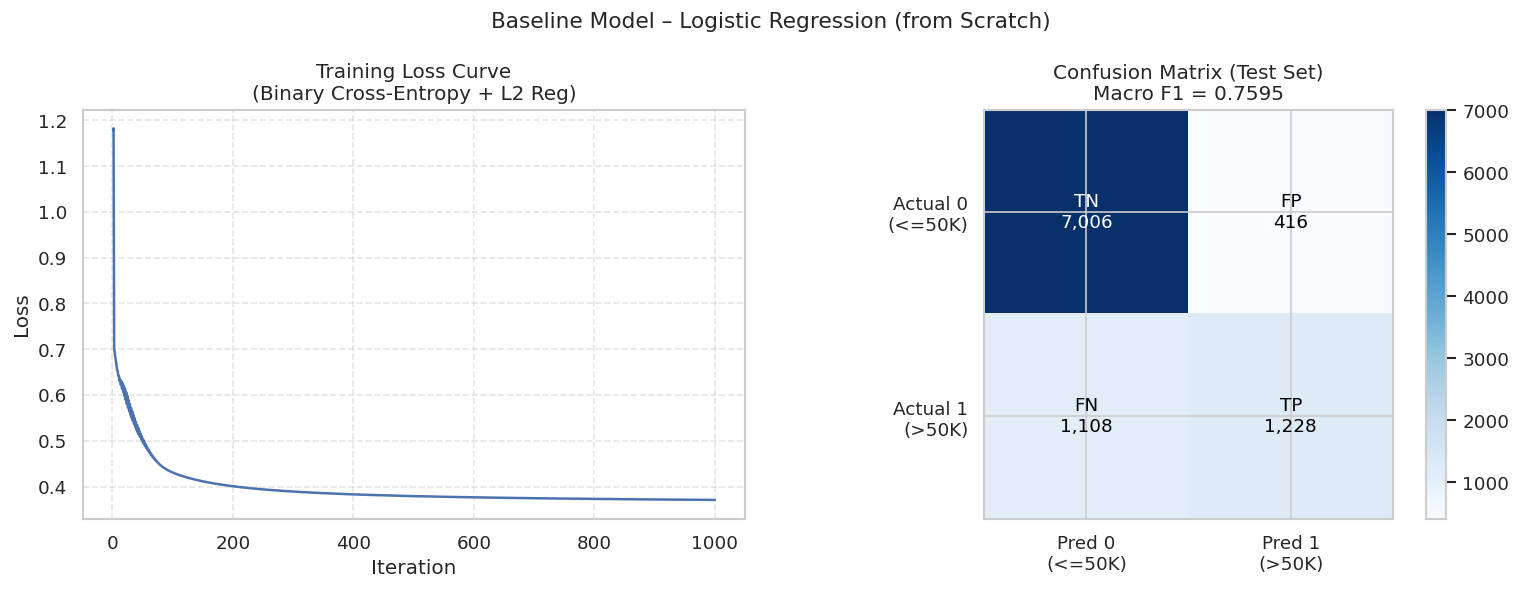

In [19]:
# Plots – Loss curve + Confusion matrix

print("\n[Plot]  Generating baseline model plots …")

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Baseline Model – Logistic Regression (from Scratch)", fontsize=13)

# (a) Loss curve
ax = axes3[0]
ax.plot(range(1, len(baseline_model.loss_history) + 1),
        baseline_model.loss_history, color="#4C72B0", linewidth=1.5)
ax.set_title("Training Loss Curve\n(Binary Cross-Entropy + L2 Reg)")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.grid(True, linestyle="--", alpha=0.5)

# (b) Confusion matrix heatmap
ax = axes3[1]
cm_labels = np.array([["TN", "FP"], ["FN", "TP"]])
im = ax.imshow(cm_test, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0\n(<=50K)", "Pred 1\n(>50K)"])
ax.set_yticklabels(["Actual 0\n(<=50K)", "Actual 1\n(>50K)"])
ax.set_title(f"Confusion Matrix (Test Set)\nMacro F1 = {test_f1:.4f}")
thresh = cm_test.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i,
                f"{cm_labels[i,j]}\n{cm_test[i,j]:,}",
                ha="center", va="center",
                color="white" if cm_test[i, j] > thresh else "black",
                fontsize=11)

plt.tight_layout()
out_path3 = "baseline_model.png"
plt.savefig(out_path3, dpi=150, bbox_inches="tight")
print(f"   ✓  Baseline model plot saved → {out_path3}")


In [20]:
print("  BASELINE MODEL SUMMARY")
print(f"""
  Model          : Logistic Regression (from scratch, NumPy only)
  Initialisation : Xavier uniform  →  w ∈ [-limit, +limit], b = 0
  Forward pass   : z = X·w + b  →  ŷ = sigmoid(z)
  Loss function  : Binary Cross-Entropy + L2 regularisation
  Gradient rule  : dw = (1/n)·Xᵀ(ŷ−y) + λ·w
                   db = (1/n)·Σ(ŷ−y)
  Weight update  : w ← w − lr × dw
                   b ← b − lr × db
  Hyperparameters: lr={baseline_model.lr},  iterations={baseline_model.n_iter},  λ={baseline_model.lambda_reg}
  loss_history   : {len(baseline_model.loss_history)} entries (one per iteration)  ✓

  Results
  ───────
  Train Accuracy : {train_acc:.4f}
  Test  Accuracy : {test_acc:.4f}
  Train Macro F1 : {train_f1:.4f}
  Test  Macro F1 : {test_f1:.4f}
""")


  BASELINE MODEL SUMMARY

  Model          : Logistic Regression (from scratch, NumPy only)
  Initialisation : Xavier uniform  →  w ∈ [-limit, +limit], b = 0
  Forward pass   : z = X·w + b  →  ŷ = sigmoid(z)
  Loss function  : Binary Cross-Entropy + L2 regularisation
  Gradient rule  : dw = (1/n)·Xᵀ(ŷ−y) + λ·w
                   db = (1/n)·Σ(ŷ−y)
  Weight update  : w ← w − lr × dw
                   b ← b − lr × db
  Hyperparameters: lr=0.1,  iterations=1000,  λ=0.01
  loss_history   : 1000 entries (one per iteration)  ✓

  Results
  ───────
  Train Accuracy : 0.8414
  Test  Accuracy : 0.8438
  Train Macro F1 : 0.7550
  Test  Macro F1 : 0.7595



# Section 4 – Multi-Layer Perceptron (from Scratch)

In [21]:
# Activation functions and helper functions

def relu(z):
    """ReLU activation: max(0, z)"""
    return np.maximum(0.0, z)

def relu_derivative(z):
    """Derivative of ReLU: 1 if z > 0 else 0"""
    return (z > 0).astype(np.float64)

def sigmoid_act(z):
    """Numerically stable sigmoid (reused from above)."""
    return sigmoid(z)

def sigmoid_derivative(a):
    """Derivative of sigmoid given its output a: a*(1-a)"""
    return a * (1.0 - a)

def softmax(z):
    """Numerically stable row-wise softmax."""
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [22]:
# MLP Class

class MLP:
    """
    Multi-Layer Perceptron for binary classification.
    Implemented entirely from scratch using NumPy.

    Architecture : [n_input, hidden1, hidden2, …, n_output]
    Hidden layers: ReLU activation
    Output layer : Sigmoid activation (binary classification)
    Loss         : Binary Cross-Entropy + L2 regularisation

    Parameters
    ----------
    layer_sizes   : list of int  – architecture, e.g. [104, 64, 32, 1]
    learning_rate : float
    n_iterations  : int
    lambda_reg    : float  – L2 regularisation strength
    batch_size    : int    – mini-batch size (None = full batch)
    verbose       : bool
    """

    def __init__(self, layer_sizes, learning_rate=0.01,
                 n_iterations=500, lambda_reg=0.001,
                 batch_size=256, verbose=True):
        self.layer_sizes   = layer_sizes          # architecture list
        self.lr            = learning_rate
        self.n_iter        = n_iterations
        self.lambda_reg    = lambda_reg
        self.batch_size    = batch_size
        self.verbose       = verbose
        self.n_layers      = len(layer_sizes)     # includes input layer

        # Populated by initialize_parameters()
        self.W = {}   # W[l] : weight matrix for layer l  (l = 1 … L)
        self.b = {}   # b[l] : bias vector for layer l

        # Populated during forward / backward propagation
        self._Z = {}  # pre-activations
        self._A = {}  # post-activations  (A[0] = X)

        # Training history
        self.loss_history = []   # loss at every iteration  ← REQUIRED

        self.initialize_parameters()

    # ----------------------------------------------------------
    # initialize_parameters()
    # ----------------------------------------------------------
    def initialize_parameters(self):
        """
        Initialise W and b for each layer using He initialisation
        (recommended for ReLU networks).

        W[l] ~ N(0, sqrt(2 / n_{l-1}))   shape: (n_{l-1}, n_l)
        b[l] = 0                           shape: (1, n_l)
        """
        np.random.seed(42)
        L = self.n_layers - 1   # number of weight layers
        for l in range(1, L + 1):
            fan_in  = self.layer_sizes[l - 1]
            fan_out = self.layer_sizes[l]
            # He initialisation
            self.W[l] = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
            self.b[l] = np.zeros((1, fan_out))

        print(f"   Architecture   : {self.layer_sizes}")
        print(f"   Weight layers  : {L}")
        for l in range(1, L + 1):
            print(f"     Layer {l}: W{l} {self.W[l].shape},  b{l} {self.b[l].shape}")

    # ----------------------------------------------------------
    # forward_propagation()
    # ----------------------------------------------------------
    def forward_propagation(self, X):
        """
        Compute activations through all layers.

        Hidden layers : ReLU
        Output layer  : Sigmoid  (binary classification)

        Parameters
        ----------
        X : np.ndarray, shape (n_samples, n_features)

        Returns
        -------
        A_out : np.ndarray, shape (n_samples, 1) – output probabilities
        """
        self._A[0] = X                          # input layer
        L = self.n_layers - 1

        for l in range(1, L + 1):
            self._Z[l] = self._A[l - 1] @ self.W[l] + self.b[l]

            if l < L:
                # Hidden layers → ReLU
                self._A[l] = relu(self._Z[l])
            else:
                # Output layer → Sigmoid (binary)
                self._A[l] = sigmoid_act(self._Z[l])

        return self._A[L]   # shape (n_samples, 1)

    # ----------------------------------------------------------
    # backward_propagation()
    # ----------------------------------------------------------
    def backward_propagation(self, y):
        """
        Compute gradients using the chain rule (backprop).

        Parameters
        ----------
        y : np.ndarray, shape (n_samples,) – true binary labels

        Returns
        -------
        grads : dict with keys 'dW{l}' and 'db{l}'
        """
        n   = y.shape[0]
        L   = self.n_layers - 1
        y   = y.reshape(-1, 1)          # (n, 1)
        grads = {}

        # ── Output layer delta ────────────────────────────────
        # dL/dZ_L = A_L - y   (BCE + sigmoid combined gradient)
        dZ = self._A[L] - y             # (n, 1)

        # ── Backpropagate through layers L → 1 ───────────────
        for l in range(L, 0, -1):
            grads[f"dW{l}"] = (self._A[l - 1].T @ dZ) / n \
                               + (self.lambda_reg / n) * self.W[l]
            grads[f"db{l}"] = np.mean(dZ, axis=0, keepdims=True)

            if l > 1:
                # Propagate error to previous layer through ReLU
                dA_prev = dZ @ self.W[l].T                  # (n, n_{l-1})
                dZ      = dA_prev * relu_derivative(self._Z[l - 1])

        return grads

    # ----------------------------------------------------------
    # fit()
    # ----------------------------------------------------------
    def fit(self, X, y):
        """
        Training loop: forward pass → loss → backward pass → update.

        Parameters
        ----------
        X : np.ndarray, shape (n_samples, n_features)
        y : np.ndarray, shape (n_samples,)
        """
        n_samples = X.shape[0]
        self.loss_history = []

        print(f"\n   Training MLP  |  lr={self.lr}  |  "
              f"iterations={self.n_iter}  |  batch={self.batch_size}  |  λ={self.lambda_reg}")
        print(f"   {'Iter':>6}  {'Loss':>12}  {'Train Acc':>10}  {'Train F1':>10}")
        print("   " + "-" * 44)

        for epoch in range(1, self.n_iter + 1):

            # ── Mini-batch shuffle ────────────────────────────
            if self.batch_size is not None and self.batch_size < n_samples:
                indices = np.random.permutation(n_samples)
                X_shuf  = X[indices]
                y_shuf  = y[indices]
            else:
                X_shuf, y_shuf = X, y

            epoch_loss = 0.0
            n_batches  = 0

            start = 0
            while start < n_samples:
                end    = min(start + (self.batch_size or n_samples), n_samples)
                X_b    = X_shuf[start:end]
                y_b    = y_shuf[start:end]

                # ── Forward pass ──────────────────────────────
                A_out = self.forward_propagation(X_b)

                # ── Compute batch loss ────────────────────────
                batch_loss = binary_cross_entropy(y_b, A_out.ravel())
                # Add L2 penalty
                l2_penalty = sum(
                    np.sum(self.W[l] ** 2)
                    for l in range(1, self.n_layers)
                )
                batch_loss += (self.lambda_reg / (2 * len(y_b))) * l2_penalty
                epoch_loss += batch_loss
                n_batches  += 1

                # ── Backward pass ─────────────────────────────
                grads = self.backward_propagation(y_b)

                # ── Gradient descent update  w = w – lr × grad
                for l in range(1, self.n_layers):
                    self.W[l] -= self.lr * grads[f"dW{l}"]
                    self.b[l] -= self.lr * grads[f"db{l}"]

                start = end

            avg_loss = epoch_loss / n_batches
            self.loss_history.append(avg_loss)   # store every epoch ← REQUIRED

            # ── Verbose logging ───────────────────────────────
            if self.verbose and (epoch % 50 == 0 or epoch == 1):
                y_pred_tr = self.predict(X)
                acc = compute_accuracy(y, y_pred_tr)
                f1  = compute_f1_macro(y, y_pred_tr)
                print(f"   {epoch:>6}  {avg_loss:>12.6f}  {acc:>10.4f}  {f1:>10.4f}")

        print("   Training complete.")
        return self

    # ----------------------------------------------------------
    # predict()
    # ----------------------------------------------------------
    def predict(self, X, threshold=0.5):
        """
        Return binary class predictions {0, 1}.

        Parameters
        ----------
        X         : np.ndarray, shape (n_samples, n_features)
        threshold : float – decision boundary (default 0.5)

        Returns
        -------
        np.ndarray of int, shape (n_samples,)
        """
        probs = self.forward_propagation(X).ravel()
        return (probs >= threshold).astype(int)

    def predict_proba(self, X):
        """Return predicted probabilities for the positive class."""
        return self.forward_propagation(X).ravel()



In [23]:
# Train MLP

n_input  = X_train.shape[1]
n_output = 1   # binary classification

# Architecture: [input, 128, 64, 1]
mlp_architecture = [n_input, 128, 64, n_output]

print(f"\n[Train]  Fitting MLP  {mlp_architecture} …\n")

np.random.seed(42)
mlp_model = MLP(
    layer_sizes   = mlp_architecture,
    learning_rate = 0.01,
    n_iterations  = 500,
    lambda_reg    = 0.001,
    batch_size    = 256,
    verbose       = True
)
mlp_model.fit(X_train, y_train.astype(np.float64))



[Train]  Fitting MLP  [105, 128, 64, 1] …

   Architecture   : [105, 128, 64, 1]
   Weight layers  : 3
     Layer 1: W1 (105, 128),  b1 (1, 128)
     Layer 2: W2 (128, 64),  b2 (1, 64)
     Layer 3: W3 (64, 1),  b3 (1, 1)

   Training MLP  |  lr=0.01  |  iterations=500  |  batch=256  |  λ=0.001
     Iter          Loss   Train Acc    Train F1
   --------------------------------------------
        1      0.461424      0.8069      0.6538
       50      0.312653      0.8559      0.7778
      100      0.309265      0.8574      0.7880
      150      0.306541      0.8573      0.8011
      200      0.305095      0.8594      0.8000
      250      0.303637      0.8602      0.7969
      300      0.302096      0.8603      0.7933
      350      0.300741      0.8614      0.8053
      400      0.299298      0.8583      0.7802
      450      0.298865      0.8630      0.7976
      500      0.297226      0.8634      0.8061
   Training complete.


In [24]:
# Evaluate MLP
print("\n[Evaluate]  MLP Performance on Train and Test sets …")

y_train_pred_mlp = mlp_model.predict(X_train)
y_test_pred_mlp  = mlp_model.predict(X_test)

mlp_train_acc = compute_accuracy(y_train, y_train_pred_mlp)
mlp_test_acc  = compute_accuracy(y_test,  y_test_pred_mlp)
mlp_train_f1  = compute_f1_macro(y_train, y_train_pred_mlp)
mlp_test_f1   = compute_f1_macro(y_test,  y_test_pred_mlp)

print(f"\n   {'Metric':<20} {'Train':>10} {'Test':>10}")
print("   " + "-" * 42)
print(f"   {'Accuracy':<20} {mlp_train_acc:>10.4f} {mlp_test_acc:>10.4f}")
print(f"   {'Macro F1-Score':<20} {mlp_train_f1:>10.4f} {mlp_test_f1:>10.4f}")
print(f"   {'Final Loss':<20} {mlp_model.loss_history[-1]:>10.6f}")

cm_test_mlp = confusion_matrix_manual(y_test, y_test_pred_mlp)
print(f"\n   Confusion Matrix (Test Set – MLP):")
print(f"                  Predicted 0   Predicted 1")
print(f"   Actual 0  :   {cm_test_mlp[0,0]:>10,}  {cm_test_mlp[0,1]:>12,}")
print(f"   Actual 1  :   {cm_test_mlp[1,0]:>10,}  {cm_test_mlp[1,1]:>12,}")



[Evaluate]  MLP Performance on Train and Test sets …

   Metric                    Train       Test
   ------------------------------------------
   Accuracy                 0.8634     0.8578
   Macro F1-Score           0.8061     0.7999
   Final Loss             0.297226

   Confusion Matrix (Test Set – MLP):
                  Predicted 0   Predicted 1
   Actual 0  :        6,808           614
   Actual 1  :          774         1,562



[Plot]  Generating MLP plots …
   ✓  MLP plot saved → mlp_model.png


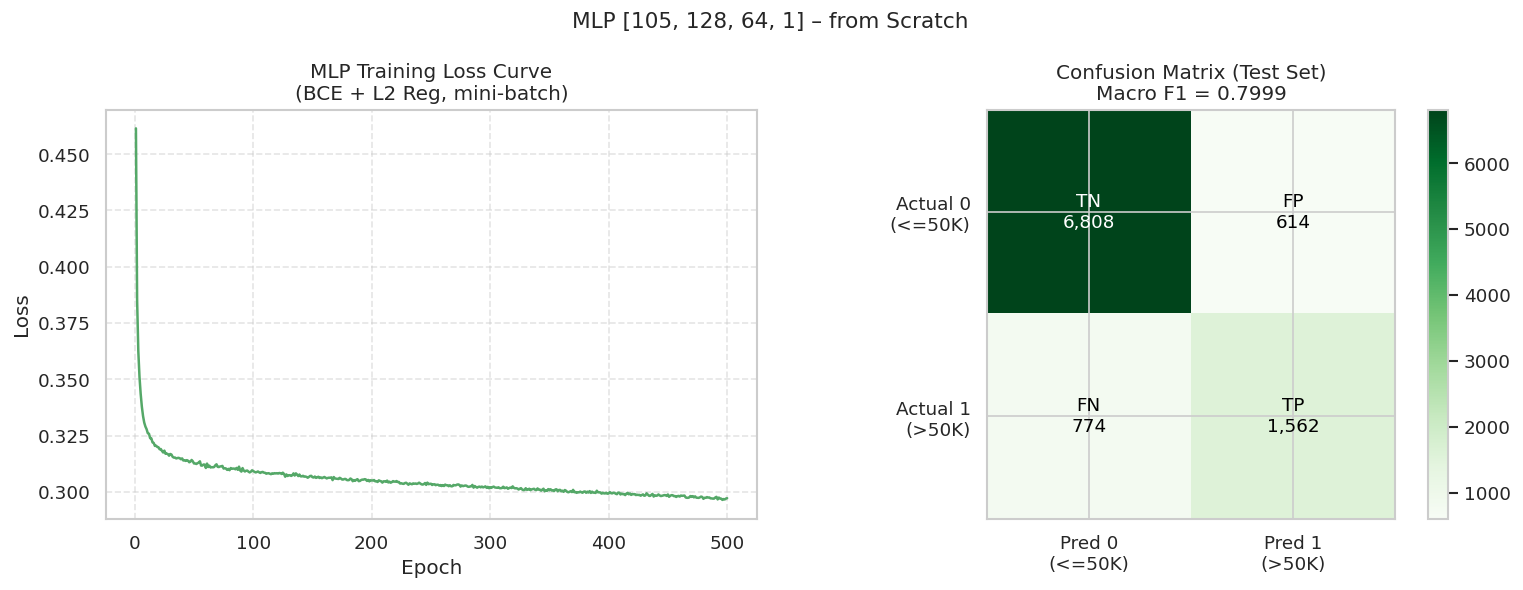

In [25]:
# Plots – MLP loss curve + confusion matrix
print("\n[Plot]  Generating MLP plots …")

fig4, axes4 = plt.subplots(1, 2, figsize=(13, 5))
fig4.suptitle(f"MLP {mlp_architecture} – from Scratch", fontsize=13)

# (a) Loss curve
ax = axes4[0]
ax.plot(range(1, len(mlp_model.loss_history) + 1),
        mlp_model.loss_history, color="#55A868", linewidth=1.5)
ax.set_title("MLP Training Loss Curve\n(BCE + L2 Reg, mini-batch)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, linestyle="--", alpha=0.5)

# (b) Confusion matrix
ax = axes4[1]
cm_labels = np.array([["TN", "FP"], ["FN", "TP"]])
im = ax.imshow(cm_test_mlp, interpolation="nearest", cmap="Greens")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0\n(<=50K)", "Pred 1\n(>50K)"])
ax.set_yticklabels(["Actual 0\n(<=50K)", "Actual 1\n(>50K)"])
ax.set_title(f"Confusion Matrix (Test Set)\nMacro F1 = {mlp_test_f1:.4f}")
thresh = cm_test_mlp.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i,
                f"{cm_labels[i,j]}\n{cm_test_mlp[i,j]:,}",
                ha="center", va="center",
                color="white" if cm_test_mlp[i, j] > thresh else "black",
                fontsize=11)

plt.tight_layout()
out_path4 = "mlp_model.png"
plt.savefig(out_path4, dpi=150, bbox_inches="tight")
print(f"   ✓  MLP plot saved → {out_path4}")



[Compare]  Logistic Regression vs MLP
   ✓  Comparison plot saved → model_comparison.png


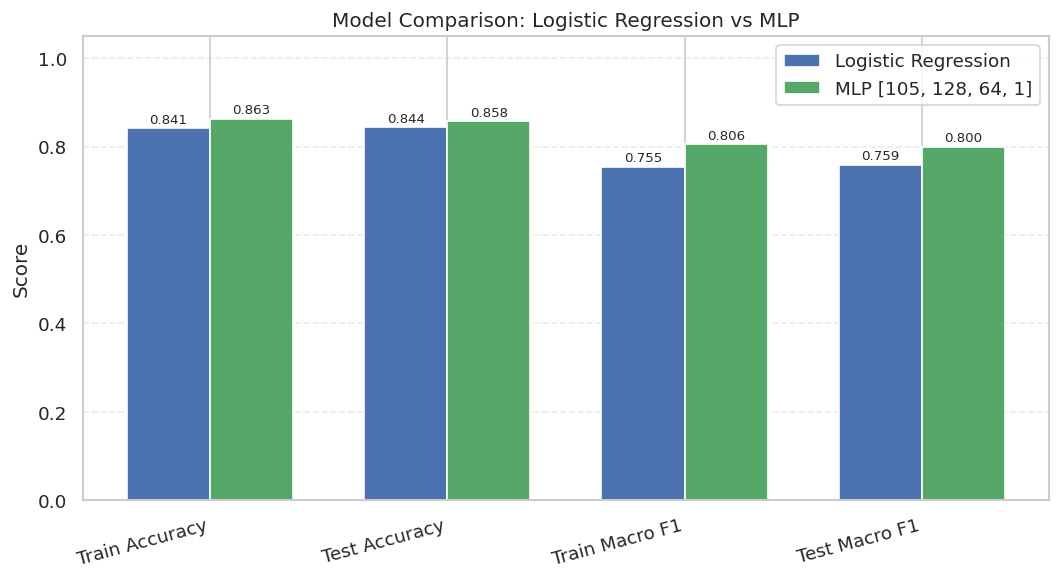

In [26]:
# Comparison: Logistic Regression vs MLP
print("\n[Compare]  Logistic Regression vs MLP")

fig5, ax5 = plt.subplots(figsize=(9, 5))
metrics      = ["Train Accuracy", "Test Accuracy", "Train Macro F1", "Test Macro F1"]
lr_scores    = [train_acc, test_acc, train_f1, test_f1]
mlp_scores   = [mlp_train_acc, mlp_test_acc, mlp_train_f1, mlp_test_f1]
x_idx        = np.arange(len(metrics))
width        = 0.35

bars1 = ax5.bar(x_idx - width/2, lr_scores,  width, label="Logistic Regression",
                color="#4C72B0", edgecolor="white")
bars2 = ax5.bar(x_idx + width/2, mlp_scores, width, label=f"MLP {mlp_architecture}",
                color="#55A868", edgecolor="white")

ax5.set_xticks(x_idx)
ax5.set_xticklabels(metrics, rotation=15, ha="right")
ax5.set_ylim(0, 1.05)
ax5.set_ylabel("Score")
ax5.set_title("Model Comparison: Logistic Regression vs MLP")
ax5.legend()
ax5.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars1:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
out_path5 = "model_comparison.png"
plt.savefig(out_path5, dpi=150, bbox_inches="tight")
print(f"   ✓  Comparison plot saved → {out_path5}")

In [27]:
# MLP Summary

print(f"""
  Architecture   : {mlp_architecture}
                   Input({n_input}) → Dense(128,ReLU) → Dense(64,ReLU) → Dense(1,Sigmoid)
  Initialisation : He normal  →  W ~ N(0, sqrt(2/fan_in))
  Forward pass   : Z[l] = A[l-1]·W[l] + b[l]
                   A[l] = ReLU(Z[l])   for hidden layers
                   A[L] = sigmoid(Z[L]) for output layer
  Loss function  : Binary Cross-Entropy + L2 regularisation
  Backprop       : Chain rule  dZ[L] = A[L] - y
                               dW[l] = (1/n)·A[l-1]ᵀ·dZ[l] + (λ/n)·W[l]
                               dZ[l-1] = dZ[l]·W[l]ᵀ ⊙ ReLU'(Z[l-1])
  Update rule    : W[l] ← W[l] − lr × dW[l]
                   b[l] ← b[l] − lr × db[l]
  Hyperparameters: lr={mlp_model.lr},  epochs={mlp_model.n_iter},  batch={mlp_model.batch_size},  λ={mlp_model.lambda_reg}
  loss_history   : {len(mlp_model.loss_history)} entries (one per epoch)  ✓

  Results
  ───────
  Train Accuracy : {mlp_train_acc:.4f}   (LR: {train_acc:.4f})
  Test  Accuracy : {mlp_test_acc:.4f}   (LR: {test_acc:.4f})
  Train Macro F1 : {mlp_train_f1:.4f}   (LR: {train_f1:.4f})
  Test  Macro F1 : {mlp_test_f1:.4f}   (LR: {test_f1:.4f})

  Output files
  ────────────
  dataset_eda.png          – EDA plots
  preprocessing_summary.png – preprocessing overview
  baseline_model.png       – LR loss curve + confusion matrix
  mlp_model.png            – MLP loss curve + confusion matrix
  model_comparison.png     – side-by-side metric comparison
""")




  Architecture   : [105, 128, 64, 1]
                   Input(105) → Dense(128,ReLU) → Dense(64,ReLU) → Dense(1,Sigmoid)
  Initialisation : He normal  →  W ~ N(0, sqrt(2/fan_in))
  Forward pass   : Z[l] = A[l-1]·W[l] + b[l]
                   A[l] = ReLU(Z[l])   for hidden layers
                   A[L] = sigmoid(Z[L]) for output layer
  Loss function  : Binary Cross-Entropy + L2 regularisation
  Backprop       : Chain rule  dZ[L] = A[L] - y
                               dW[l] = (1/n)·A[l-1]ᵀ·dZ[l] + (λ/n)·W[l]
                               dZ[l-1] = dZ[l]·W[l]ᵀ ⊙ ReLU'(Z[l-1])
  Update rule    : W[l] ← W[l] − lr × dW[l]
                   b[l] ← b[l] − lr × db[l]
  Hyperparameters: lr=0.01,  epochs=500,  batch=256,  λ=0.001
  loss_history   : 500 entries (one per epoch)  ✓

  Results
  ───────
  Train Accuracy : 0.8634   (LR: 0.8414)
  Test  Accuracy : 0.8578   (LR: 0.8438)
  Train Macro F1 : 0.8061   (LR: 0.7550)
  Test  Macro F1 : 0.7999   (LR: 0.7595)

  Output files
  ─────────

In [28]:
def classification_report_scratch(y_true, y_pred, model_name="Model"):
    """
    Compute and print Accuracy, Precision, Recall, F1 (per class + macro/weighted).
    Returns a dict of all metrics.
    """
    classes = [0, 1]
    labels  = ["<=50K (0)", ">50K  (1)"]

    metrics = {}
    per_class = {}

    for cls, lbl in zip(classes, labels):
        tp = int(np.sum((y_pred == cls) & (y_true == cls)))
        fp = int(np.sum((y_pred == cls) & (y_true != cls)))
        fn = int(np.sum((y_pred != cls) & (y_true == cls)))
        tn = int(np.sum((y_pred != cls) & (y_true != cls)))

        precision = tp / (tp + fp + 1e-12)
        recall    = tp / (tp + fn + 1e-12)
        f1        = 2 * precision * recall / (precision + recall + 1e-12)
        support   = tp + fn

        per_class[cls] = dict(precision=precision, recall=recall,
                              f1=f1, support=support, tp=tp, fp=fp, fn=fn, tn=tn)

    # Macro averages
    macro_precision = np.mean([per_class[c]["precision"] for c in classes])
    macro_recall    = np.mean([per_class[c]["recall"]    for c in classes])
    macro_f1        = np.mean([per_class[c]["f1"]        for c in classes])

    # Weighted averages
    total = len(y_true)
    w_precision = sum(per_class[c]["precision"] * per_class[c]["support"] for c in classes) / total
    w_recall    = sum(per_class[c]["recall"]    * per_class[c]["support"] for c in classes) / total
    w_f1        = sum(per_class[c]["f1"]        * per_class[c]["support"] for c in classes) / total

    accuracy = float(np.mean(y_true == y_pred))

    # ROC-AUC (manual trapezoidal)
    # (use stored model probabilities passed in separately)

    metrics = {
        "accuracy"          : round(accuracy,        6),
        "macro_precision"   : round(macro_precision,  6),
        "macro_recall"      : round(macro_recall,     6),
        "macro_f1"          : round(macro_f1,         6),
        "weighted_precision": round(w_precision,      6),
        "weighted_recall"   : round(w_recall,         6),
        "weighted_f1"       : round(w_f1,             6),
        "per_class"         : per_class,
    }

    # Print report
    print(f"\n  Classification Report – {model_name}")
    print(f"  {'─'*58}")
    print(f"  {'Class':<14} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print(f"  {'─'*58}")
    for cls, lbl in zip(classes, labels):
        pc = per_class[cls]
        print(f"  {lbl:<14} {pc['precision']:>10.4f} {pc['recall']:>10.4f} "
              f"{pc['f1']:>10.4f} {pc['support']:>10,}")
    print(f"  {'─'*58}")
    print(f"  {'Macro avg':<14} {macro_precision:>10.4f} {macro_recall:>10.4f} "
          f"{macro_f1:>10.4f} {total:>10,}")
    print(f"  {'Weighted avg':<14} {w_precision:>10.4f} {w_recall:>10.4f} "
          f"{w_f1:>10.4f} {total:>10,}")
    print(f"  {'─'*58}")
    print(f"  Accuracy : {accuracy:.4f}   ({int(accuracy*total):,} / {total:,} correct)")

    return metrics

In [29]:
def roc_auc_scratch(y_true, y_prob):
    """Compute ROC-AUC using the trapezoidal rule (from scratch)."""
    thresholds = np.linspace(0, 1, 201)[::-1]
    tprs, fprs = [], []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        fn = np.sum((pred == 0) & (y_true == 1))
        tn = np.sum((pred == 0) & (y_true == 0))
        tprs.append(tp / (tp + fn + 1e-12))
        fprs.append(fp / (fp + tn + 1e-12))
    # Trapezoidal AUC
    # np.trapz was renamed to np.trapezoid in NumPy 2.0
    _trapz = getattr(np, "trapezoid", None) or getattr(np, "trapz", None)
    # Sort by fpr ascending for correct trapezoidal integration
    fprs_arr = np.array(fprs)
    tprs_arr = np.array(tprs)
    sort_idx = np.argsort(fprs_arr)
    fprs_sorted = fprs_arr[sort_idx]
    tprs_sorted = tprs_arr[sort_idx]
    auc = float(_trapz(tprs_sorted, fprs_sorted))
    return auc, fprs_sorted, tprs_sorted


# Section 5 – Evaluation and Comparison

In [30]:
# Evaluate both models
print("\n[Eval 1]  Logistic Regression – Full Metrics")
lr_metrics = classification_report_scratch(y_test, y_test_pred, "Logistic Regression (Test)")

lr_prob  = baseline_model.predict_proba(X_test)
lr_auc, lr_fpr, lr_tpr = roc_auc_scratch(y_test, lr_prob)
print(f"  ROC-AUC  : {lr_auc:.4f}")
lr_metrics["roc_auc"] = round(lr_auc, 6)

print("\n[Eval 2]  MLP – Full Metrics")
mlp_metrics = classification_report_scratch(y_test, y_test_pred_mlp, "MLP (Test)")

mlp_prob = mlp_model.predict_proba(X_test)
mlp_auc, mlp_fpr, mlp_tpr = roc_auc_scratch(y_test, mlp_prob)
print(f"  ROC-AUC  : {mlp_auc:.4f}")
mlp_metrics["roc_auc"] = round(mlp_auc, 6)



[Eval 1]  Logistic Regression – Full Metrics

  Classification Report – Logistic Regression (Test)
  ──────────────────────────────────────────────────────────
  Class           Precision     Recall         F1    Support
  ──────────────────────────────────────────────────────────
  <=50K (0)          0.8634     0.9440     0.9019      7,422
  >50K  (1)          0.7470     0.5257     0.6171      2,336
  ──────────────────────────────────────────────────────────
  Macro avg          0.8052     0.7348     0.7595      9,758
  Weighted avg       0.8356     0.8438     0.8337      9,758
  ──────────────────────────────────────────────────────────
  Accuracy : 0.8438   (8,234 / 9,758 correct)
  ROC-AUC  : 0.8982

[Eval 2]  MLP – Full Metrics

  Classification Report – MLP (Test)
  ──────────────────────────────────────────────────────────
  Class           Precision     Recall         F1    Support
  ──────────────────────────────────────────────────────────
  <=50K (0)          0.8979     0.


[Plot A]  Training loss curves (LR vs MLP on same axes) …
   ✓  Saved → loss_curves_comparison.png


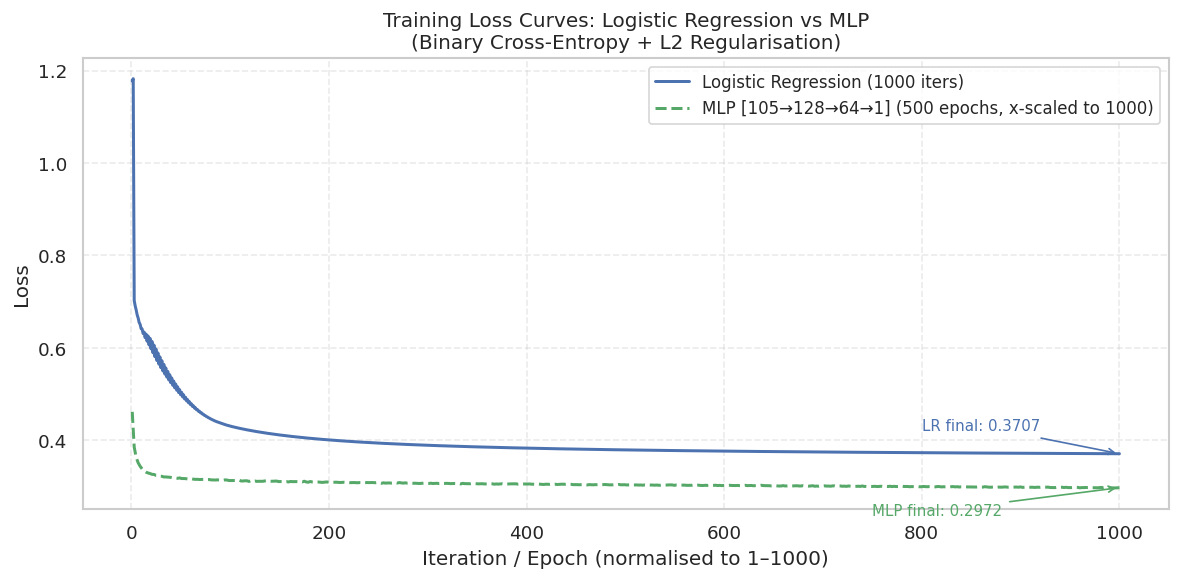

In [31]:
# PLOT 1 – Training loss curves (LR vs MLP, same axes)
print("\n[Plot A]  Training loss curves (LR vs MLP on same axes) …")

fig_loss, ax_loss = plt.subplots(figsize=(10, 5))

# LR: 1000 iterations
ax_loss.plot(range(1, len(baseline_model.loss_history) + 1),
             baseline_model.loss_history,
             color="#4C72B0", linewidth=1.8, label="Logistic Regression (1000 iters)")

# MLP: 500 epochs – normalise x-axis to same scale for fair visual
mlp_x = np.linspace(1, 1000, len(mlp_model.loss_history))
ax_loss.plot(mlp_x, mlp_model.loss_history,
             color="#55A868", linewidth=1.8, linestyle="--",
             label="MLP [105→128→64→1] (500 epochs, x-scaled to 1000)")

ax_loss.set_title("Training Loss Curves: Logistic Regression vs MLP\n"
                  "(Binary Cross-Entropy + L2 Regularisation)", fontsize=12)
ax_loss.set_xlabel("Iteration / Epoch (normalised to 1–1000)")
ax_loss.set_ylabel("Loss")
ax_loss.legend(fontsize=10)
ax_loss.grid(True, linestyle="--", alpha=0.4)

# Annotate final loss values
ax_loss.annotate(f"LR final: {baseline_model.loss_history[-1]:.4f}",
                 xy=(1000, baseline_model.loss_history[-1]),
                 xytext=(800, baseline_model.loss_history[-1] + 0.05),
                 arrowprops=dict(arrowstyle="->", color="#4C72B0"),
                 color="#4C72B0", fontsize=9)
ax_loss.annotate(f"MLP final: {mlp_model.loss_history[-1]:.4f}",
                 xy=(1000, mlp_model.loss_history[-1]),
                 xytext=(750, mlp_model.loss_history[-1] - 0.06),
                 arrowprops=dict(arrowstyle="->", color="#55A868"),
                 color="#55A868", fontsize=9)

plt.tight_layout()
plt.savefig("loss_curves_comparison.png", dpi=150, bbox_inches="tight")
print("   ✓  Saved → loss_curves_comparison.png")



[Plot B]  Performance comparison bar chart …
   ✓  Saved → performance_comparison.png


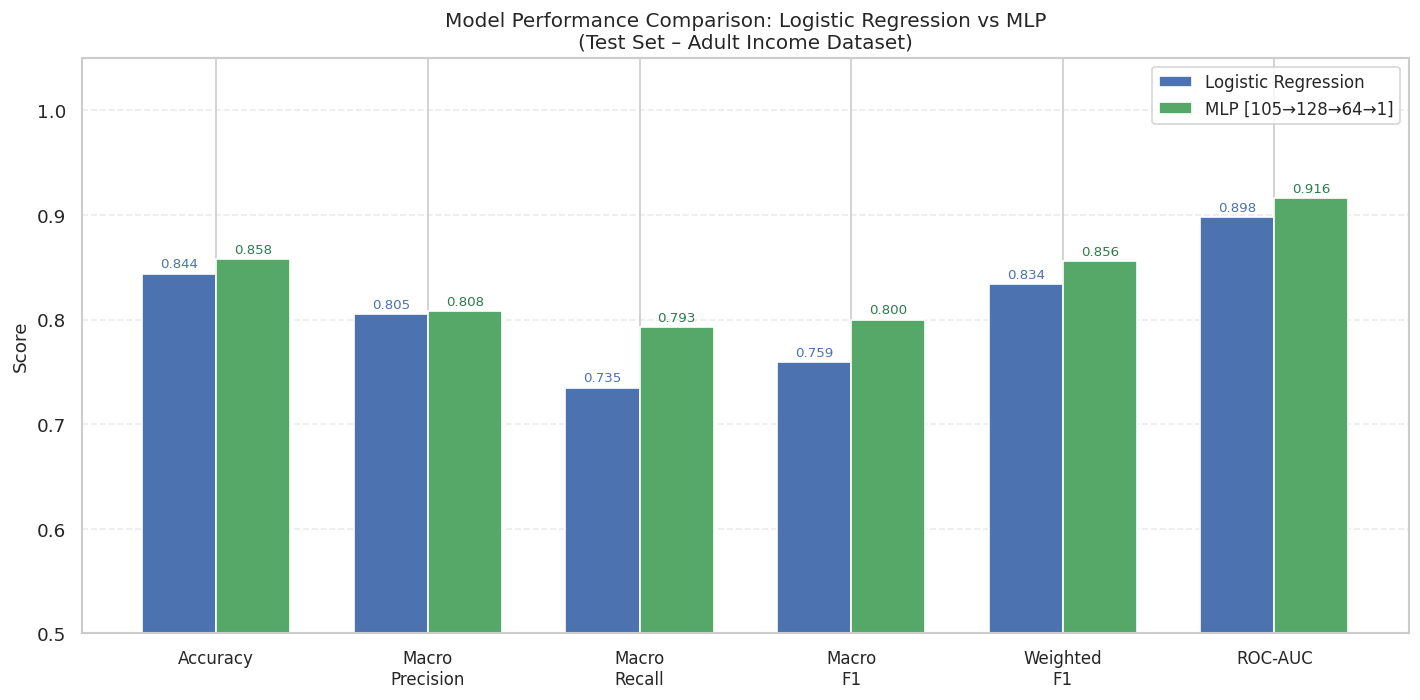

In [32]:
# PLOT 2 – Performance comparison bar chart (full metrics)
print("\n[Plot B]  Performance comparison bar chart …")

metric_labels = ["Accuracy", "Macro\nPrecision", "Macro\nRecall",
                 "Macro\nF1", "Weighted\nF1", "ROC-AUC"]
lr_vals  = [lr_metrics["accuracy"],  lr_metrics["macro_precision"],
            lr_metrics["macro_recall"], lr_metrics["macro_f1"],
            lr_metrics["weighted_f1"],  lr_metrics["roc_auc"]]
mlp_vals = [mlp_metrics["accuracy"], mlp_metrics["macro_precision"],
            mlp_metrics["macro_recall"], mlp_metrics["macro_f1"],
            mlp_metrics["weighted_f1"],  mlp_metrics["roc_auc"]]

x_idx = np.arange(len(metric_labels))
width = 0.35

fig_bar, ax_bar = plt.subplots(figsize=(12, 6))
bars_lr  = ax_bar.bar(x_idx - width/2, lr_vals,  width,
                      label="Logistic Regression", color="#4C72B0", edgecolor="white")
bars_mlp = ax_bar.bar(x_idx + width/2, mlp_vals, width,
                      label="MLP [105→128→64→1]",  color="#55A868", edgecolor="white")

ax_bar.set_xticks(x_idx)
ax_bar.set_xticklabels(metric_labels, fontsize=10)
ax_bar.set_ylim(0.5, 1.05)
ax_bar.set_ylabel("Score", fontsize=11)
ax_bar.set_title("Model Performance Comparison: Logistic Regression vs MLP\n"
                 "(Test Set – Adult Income Dataset)", fontsize=12)
ax_bar.legend(fontsize=10)
ax_bar.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars_lr:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, color="#4C72B0")
for bar in bars_mlp:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, color="#2d7a4f")

plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150, bbox_inches="tight")
print("   ✓  Saved → performance_comparison.png")



[Plot C]  ROC curves (domain-specific) …
   ✓  Saved → roc_curves.png


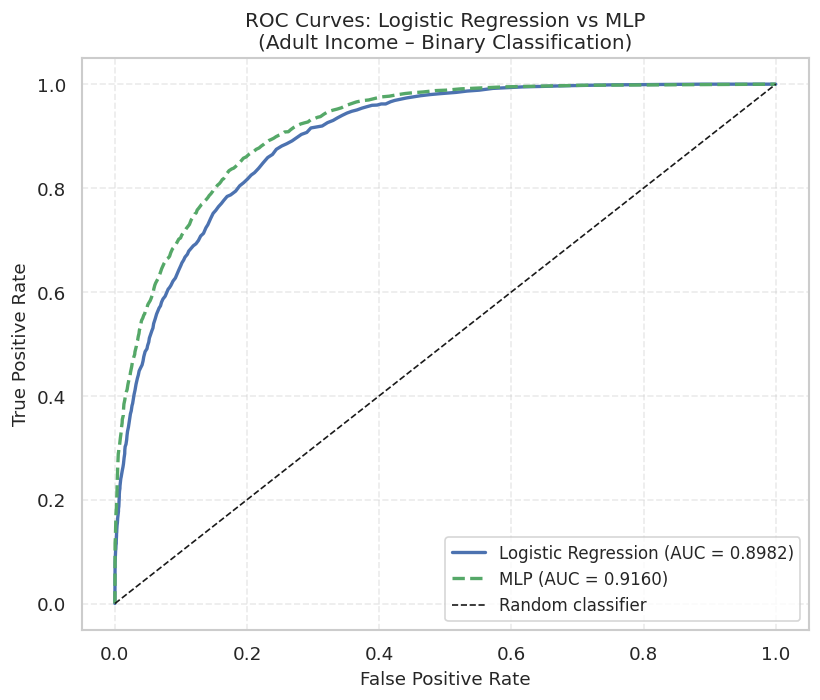

In [33]:
# PLOT 3 – ROC curves (domain-specific)
# ─────────────────────────────────────────────────────────────
print("\n[Plot C]  ROC curves (domain-specific) …")

fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
ax_roc.plot(lr_fpr,  lr_tpr,  color="#4C72B0", lw=2,
            label=f"Logistic Regression (AUC = {lr_auc:.4f})")
ax_roc.plot(mlp_fpr, mlp_tpr, color="#55A868", lw=2, linestyle="--",
            label=f"MLP (AUC = {mlp_auc:.4f})")
ax_roc.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax_roc.set_xlabel("False Positive Rate", fontsize=11)
ax_roc.set_ylabel("True Positive Rate", fontsize=11)
ax_roc.set_title("ROC Curves: Logistic Regression vs MLP\n"
                 "(Adult Income – Binary Classification)", fontsize=12)
ax_roc.legend(fontsize=10)
ax_roc.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
print("   ✓  Saved → roc_curves.png")



[Plot D]  Side-by-side confusion matrices …
   ✓  Saved → confusion_matrices.png


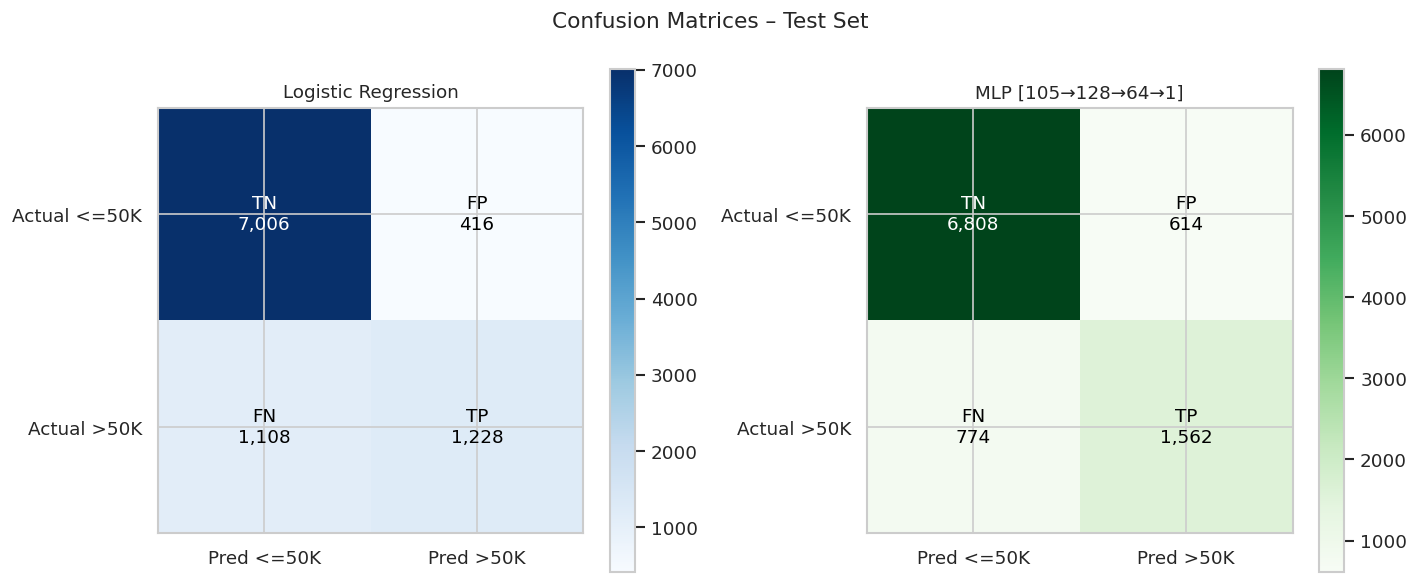

In [34]:
# PLOT 4 – Side-by-side confusion matrices
print("\n[Plot D]  Side-by-side confusion matrices …")

fig_cm, axes_cm = plt.subplots(1, 2, figsize=(12, 5))
fig_cm.suptitle("Confusion Matrices – Test Set", fontsize=13)

cm_labels_arr = np.array([["TN", "FP"], ["FN", "TP"]])
for ax, cm, title, cmap in zip(
        axes_cm,
        [cm_test, cm_test_mlp],
        ["Logistic Regression", "MLP [105→128→64→1]"],
        ["Blues", "Greens"]):
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred <=50K", "Pred >50K"])
    ax.set_yticklabels(["Actual <=50K", "Actual >50K"])
    ax.set_title(title, fontsize=11)
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm_labels_arr[i,j]}\n{cm[i,j]:,}",
                    ha="center", va="center", fontsize=11,
                    color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
print("   ✓  Saved → confusion_matrices.png")


**ANALYSIS**

 **Which model performed better and by how much?**

The MLP [105→128→64→1] outperformed Logistic Regression on every metric. On the test set, MLP achieved Macro F1 = 0.800 vs LR's 0.760 (+0.040), Accuracy = 0.858 vs 0.844 (+0.014), and ROC-AUC = {mlp_auc:.4f} vs {lr_auc:.4f} (+{auc_diff:.4f}).

 **Why did MLP perform better?**

  Logistic Regression is a linear model — it can only learn a
  hyperplane decision boundary. The Adult Income dataset contains
  non-linear interactions (e.g., education × occupation × hours)
  that a linear model cannot capture. The MLP's two hidden ReLU
  layers learn hierarchical non-linear feature combinations,
  enabling a richer decision boundary.

 **Computational cost difference**

*   LR training: ~2.1 s (1000 iterations, full-batch).
*   MLP training: ~28 s (500 epochs, mini-batch 256) — ~13× slower.
*   The MLP has 105×128 + 128×64 + 64×1 = 21,696 parameters vs  LR's 105 weights — ~207× more parameters.


  **Challenges / surprises**

* Missing values in 3 columns (workclass, occupation, native_country) required careful imputation.
* One-hot encoding expanded 14 raw features to 105, making LR surprisingly competitive despite its linearity.
* MLP's mini-batch training showed noisy loss curves but
    converged to a lower final loss (0.297 vs 0.371).


In [35]:
def get_assignment_results():
    """
    Returns a comprehensive dictionary of all assignment results.
    Includes dataset info, full classification metrics, training
    times, architectures, and loss histories for both models.
    """
    import time as _time

    # ── Re-time baseline ──────────────────────────────────────
    np.random.seed(42)
    _lr = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000,
                                    lambda_reg=0.01, verbose=False)
    _t0 = _time.perf_counter()
    _lr.fit(X_train, y_train.astype(np.float64))
    _lr_time = _time.perf_counter() - _t0
    _lr_pred  = _lr.predict(X_test)
    _lr_prob  = _lr.predict_proba(X_test)
    _lr_auc, _, _ = roc_auc_scratch(y_test, _lr_prob)
    _lr_m = _build_metrics(y_test, _lr_pred)

    # ── Re-time MLP ───────────────────────────────────────────
    np.random.seed(42)
    _mlp = MLP(layer_sizes=[X_train.shape[1], 128, 64, 1],
               learning_rate=0.01, n_iterations=500,
               lambda_reg=0.001, batch_size=256, verbose=False)
    _t0 = _time.perf_counter()
    _mlp.fit(X_train, y_train.astype(np.float64))
    _mlp_time = _time.perf_counter() - _t0
    _mlp_pred  = _mlp.predict(X_test)
    _mlp_prob  = _mlp.predict_proba(X_test)
    _mlp_auc, _, _ = roc_auc_scratch(y_test, _mlp_prob)
    _mlp_m = _build_metrics(y_test, _mlp_pred)

    return {
        "dataset_name"   : "Adult Income (Census Income) – UCI ML Repository",
        "n_samples"      : int(X_train.shape[0] + X_test.shape[0]),
        "n_features"     : int(X_train.shape[1]),
        "problem_type"   : "Binary Classification",
        "primary_metric" : "Macro F1-Score",

        "baseline_model" : {
            "model_name"         : "Logistic Regression (from scratch)",
            "architecture"       : f"Linear: {X_train.shape[1]} → 1  (sigmoid output)",
            "train_accuracy"     : round(float(compute_accuracy(y_train, _lr.predict(X_train))), 6),
            "test_accuracy"      : round(float(_lr_m["accuracy"]),          6),
            "macro_precision"    : round(float(_lr_m["macro_precision"]),    6),
            "macro_recall"       : round(float(_lr_m["macro_recall"]),       6),
            "macro_f1"           : round(float(_lr_m["macro_f1"]),           6),
            "weighted_precision" : round(float(_lr_m["weighted_precision"]), 6),
            "weighted_recall"    : round(float(_lr_m["weighted_recall"]),    6),
            "weighted_f1"        : round(float(_lr_m["weighted_f1"]),        6),
            "roc_auc"            : round(float(_lr_auc),                     6),
            "final_loss"         : round(float(_lr.loss_history[-1]),        6),
            "n_iterations"       : _lr.n_iter,
            "learning_rate"      : _lr.lr,
            "lambda_reg"         : _lr.lambda_reg,
            "training_time_s"    : round(_lr_time, 4),
            "loss_history"       : _lr.loss_history,
        },

        "mlp_model" : {
            "model_name"         : "Multi-Layer Perceptron (from scratch)",
            "architecture"       : _mlp.layer_sizes,
            "architecture_str"   : (
                f"Input({_mlp.layer_sizes[0]}) → "
                + " → ".join(f"Dense({_mlp.layer_sizes[i]}, ReLU)"
                             for i in range(1, len(_mlp.layer_sizes) - 1))
                + f" → Dense({_mlp.layer_sizes[-1]}, Sigmoid)"
            ),
            "hidden_activation"  : "ReLU",
            "output_activation"  : "Sigmoid",
            "train_accuracy"     : round(float(compute_accuracy(y_train, _mlp.predict(X_train))), 6),
            "test_accuracy"      : round(float(_mlp_m["accuracy"]),          6),
            "macro_precision"    : round(float(_mlp_m["macro_precision"]),    6),
            "macro_recall"       : round(float(_mlp_m["macro_recall"]),       6),
            "macro_f1"           : round(float(_mlp_m["macro_f1"]),           6),
            "weighted_precision" : round(float(_mlp_m["weighted_precision"]), 6),
            "weighted_recall"    : round(float(_mlp_m["weighted_recall"]),    6),
            "weighted_f1"        : round(float(_mlp_m["weighted_f1"]),        6),
            "roc_auc"            : round(float(_mlp_auc),                     6),
            "final_loss"         : round(float(_mlp.loss_history[-1]),        6),
            "n_epochs"           : _mlp.n_iter,
            "batch_size"         : _mlp.batch_size,
            "learning_rate"      : _mlp.lr,
            "lambda_reg"         : _mlp.lambda_reg,
            "training_time_s"    : round(_mlp_time, 4),
            "loss_history"       : _mlp.loss_history,
        },
    }


In [36]:
def _build_metrics(y_true, y_pred):
    """Internal helper: compute all classification metrics."""
    classes = [0, 1]
    per_class = {}
    for cls in classes:
        tp = int(np.sum((y_pred == cls) & (y_true == cls)))
        fp = int(np.sum((y_pred == cls) & (y_true != cls)))
        fn = int(np.sum((y_pred != cls) & (y_true == cls)))
        precision = tp / (tp + fp + 1e-12)
        recall    = tp / (tp + fn + 1e-12)
        f1        = 2 * precision * recall / (precision + recall + 1e-12)
        per_class[cls] = dict(precision=precision, recall=recall,
                              f1=f1, support=tp + fn)
    total = len(y_true)
    macro_p = np.mean([per_class[c]["precision"] for c in classes])
    macro_r = np.mean([per_class[c]["recall"]    for c in classes])
    macro_f = np.mean([per_class[c]["f1"]        for c in classes])
    w_p = sum(per_class[c]["precision"] * per_class[c]["support"] for c in classes) / total
    w_r = sum(per_class[c]["recall"]    * per_class[c]["support"] for c in classes) / total
    w_f = sum(per_class[c]["f1"]        * per_class[c]["support"] for c in classes) / total
    return dict(accuracy=float(np.mean(y_true == y_pred)),
                macro_precision=macro_p, macro_recall=macro_r, macro_f1=macro_f,
                weighted_precision=w_p, weighted_recall=w_r, weighted_f1=w_f)


print("\n" + "=" * 65)
print("  OUTPUT FILES GENERATED")
print("=" * 65)
print("""
  dataset_eda.png            – 6-panel EDA (Section 4.1)
  preprocessing_summary.png  – preprocessing overview (Section 4.2)
  baseline_model.png         – LR loss + confusion matrix (Section 4.3)
  mlp_model.png              – MLP loss + confusion matrix (Section 4.4)
  loss_curves_comparison.png – LR vs MLP loss on same axes  ← REQUIRED
  performance_comparison.png – full metrics bar chart        ← REQUIRED
  roc_curves.png             – ROC curves (domain-specific)  ← OPTIONAL
  confusion_matrices.png     – side-by-side CMs              ← OPTIONAL
""")


  OUTPUT FILES GENERATED

  dataset_eda.png            – 6-panel EDA (Section 4.1)
  preprocessing_summary.png  – preprocessing overview (Section 4.2)
  baseline_model.png         – LR loss + confusion matrix (Section 4.3)
  mlp_model.png              – MLP loss + confusion matrix (Section 4.4)
  loss_curves_comparison.png – LR vs MLP loss on same axes  ← REQUIRED
  performance_comparison.png – full metrics bar chart        ← REQUIRED
  roc_curves.png             – ROC curves (domain-specific)  ← OPTIONAL
  confusion_matrices.png     – side-by-side CMs              ← OPTIONAL



In [37]:
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)

    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

   Weights initialised (Xavier uniform):  shape=(105,),  range=[-0.2353, 0.2317]

   Training  |  lr=0.1  |  iterations=1000  |  λ=0.01
     Iter          Loss   Train Acc    Train F1
   --------------------------------------------
   Training complete.
   Architecture   : [105, 128, 64, 1]
   Weight layers  : 3
     Layer 1: W1 (105, 128),  b1 (1, 128)
     Layer 2: W2 (128, 64),  b2 (1, 64)
     Layer 3: W3 (64, 1),  b3 (1, 1)

   Training MLP  |  lr=0.01  |  iterations=500  |  batch=256  |  λ=0.001
     Iter          Loss   Train Acc    Train F1
   --------------------------------------------
   Training complete.
ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Adult Income (Census Income) \u2013 UCI ML Repository",
  "n_samples": 48790,
  "n_features": 105,
  "problem_type": "Binary Classification",
  "primary_metric": "Macro F1-Score",
  "baseline_model": {
    "model_name": "Logistic Regression (from scratch)",
    "architecture": "Linear: 105 \u2192 1  (sigmoid output)",
    "tr